In [1]:
import pandas as pd

dfs = []

# -----------------------
# Fake dataset
# -----------------------

fake = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\News_Dataset\Fake.csv")

fake['label'] = 0
fake['source'] = "fake_dataset"

fake = fake[['title','text','subject','date','label','source']]

dfs.append(fake)


# -----------------------
# True dataset
# -----------------------

true = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\News_Dataset\True.csv")

true['label'] = 1
true['source'] = "true_dataset"

true = true[['title','text','subject','date','label','source']]

dfs.append(true)


# -----------------------
# WELFake dataset
# -----------------------

wel = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\News_Dataset\WELFake_Dataset.csv")

wel = wel.rename(columns={
    "label": "label"
})

wel["source"] = "welfake_dataset"
wel["subject"] = None
wel["date"] = None

wel = wel[["title","text","subject","date","label","source"]]

# remove NaN
wel["text"] = wel["text"].fillna("")

# word count
wel["word_count"] = wel["text"].apply(lambda x: len(x.split()))

# keep only <150 words
wel = wel[wel["word_count"] < 150]

# drop helper column
wel = wel.drop(columns=["word_count"])

dfs.append(wel)

# -----------------------
# Merge all
# -----------------------

news_df = pd.concat(dfs, ignore_index=True)

news_df['id'] = range(len(news_df))

news_df = news_df[['id','source','title','text','subject','date','label']]

news_df = news_df.dropna(subset=['text'])

news_df.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\news_dataset.csv", index=False)

print("Final news dataset shape:", news_df.shape)

Final news dataset shape: (57361, 7)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Consistent plot style across all notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
print(f"Shape: {news_df.shape}")
print(f"Columns: {news_df.columns.tolist()}")
print(f"Missing values:\n{news_df.isnull().sum()}")
news_df.head(3)

Shape: (57361, 7)
Columns: ['id', 'source', 'title', 'text', 'subject', 'date', 'label']
Missing values:
id             0
source         0
title        512
text           0
subject    12463
date       12463
label          0
dtype: int64


,id,source,title,text,subject,date,label
0,0,fake_dataset,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,1,fake_dataset,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,2,fake_dataset,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0


label
0    29602
1    27759
Name: count, dtype: int64

Class ratio: 0.94


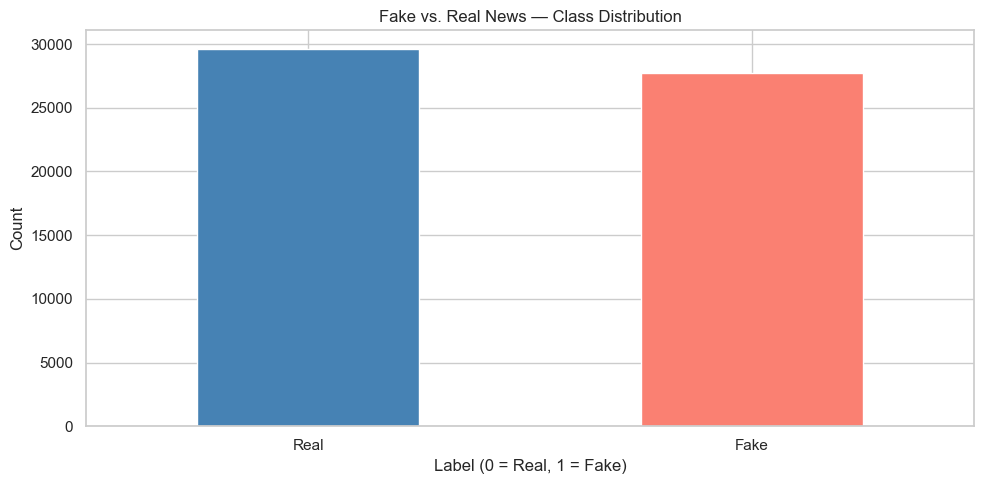

In [4]:
label_counts = news_df["label"].value_counts()
print(label_counts)
print(f"\nClass ratio: {label_counts.min() / label_counts.max():.2f}")

ax = label_counts.plot(kind="bar", color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Fake vs. Real News — Class Distribution")
ax.set_xlabel("Label (0 = Real, 1 = Fake)")
ax.set_ylabel("Count")
ax.set_xticklabels(["Real", "Fake"], rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\news\label_distribution.png", dpi=150)
plt.show()

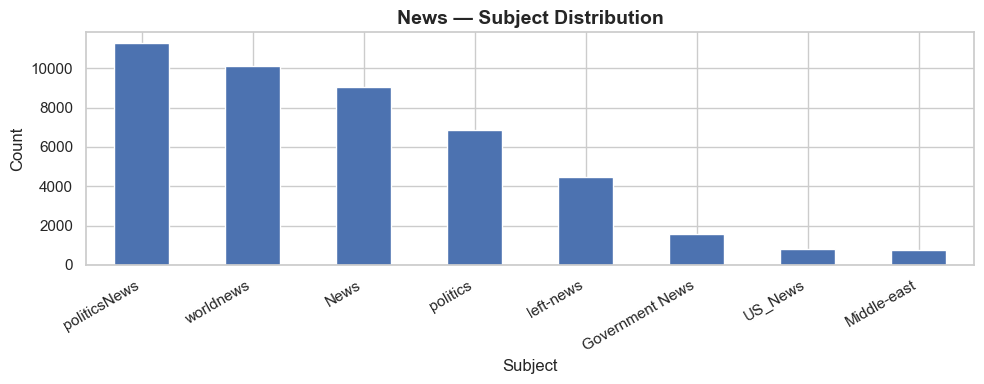

In [5]:
# Cell 3 — Subject Distribution
fig, ax = plt.subplots(figsize=(10, 4))
news_df["subject"].value_counts().plot(
    kind="bar", ax=ax, color="#4C72B0", edgecolor="white"
)
ax.set_title("News — Subject Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Subject")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\news\subject_distribution.png", dpi=150)
plt.show()

count    57361.000000
mean      2030.941964
std       2097.683538
min          0.000000
25%        595.000000
50%       1755.000000
75%       2759.000000
max      51794.000000
Name: text_length, dtype: float64


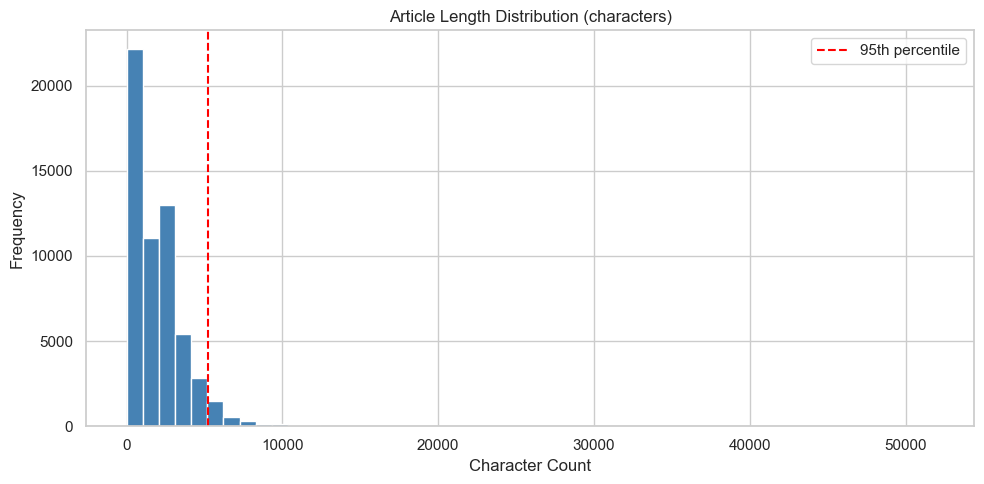

In [6]:
news_df["text_length"] = news_df["text"].str.len()

print(news_df["text_length"].describe())

news_df["text_length"].hist(bins=50, color="steelblue", edgecolor="white")
plt.title("Article Length Distribution (characters)")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.axvline(news_df["text_length"].quantile(0.95), color="red", linestyle="--", label="95th percentile")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\news\article_length.png", dpi=150)
plt.show()

In [7]:
for label, name in [(0, "Real"), (1, "Fake")]:
    subset = news_df[news_df["label"] == label]["text"]
    vec = CountVectorizer(stop_words="english", max_features=20)
    vec.fit_transform(subset)
    print(f"\nTop 20 words — {name} News:")
    print(vec.get_feature_names_out())


Top 20 words — Real News:
['american' 'campaign' 'clinton' 'donald' 'hillary' 'house' 'just' 'like'
 'media' 'new' 'news' 'obama' 'people' 'president' 'said' 'state' 'time'
 'trump' 'twitter' 'white']

Top 20 words — Fake News:
['campaign' 'clinton' 'donald' 'election' 'government' 'house' 'new'
 'party' 'people' 'president' 'republican' 'reuters' 'said' 'state'
 'states' 'told' 'trump' 'united' 'washington' 'year']


In [8]:
from wordcloud import WordCloud

In [9]:
#to combine all the tweets
sentences_0 = news_df[news_df["label"]== 0]["text"].tolist()
len(sentences_0)

29602

In [10]:
sentences_to_string_0 = " ".join(sentences_0)

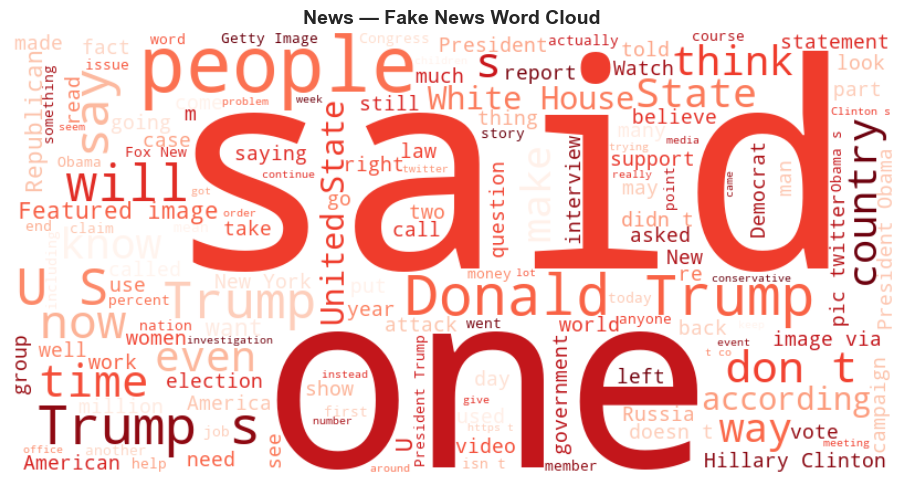

In [11]:
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="Reds", max_words=150).generate(sentences_to_string_0)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("News — Fake News Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\news\wordcloud_fake.png", dpi=150)
plt.show()

In [12]:
sentences_1 = news_df[news_df["label"]== 1]["text"].tolist()
len(sentences_1)

27759

In [13]:
sentences_to_string_1 = " ".join(sentences_1)

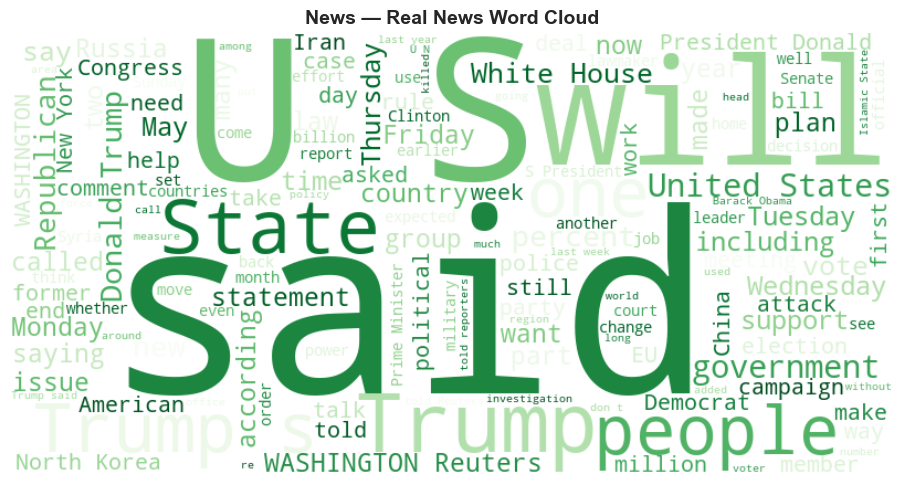


All News EDA images saved to reports/eda/news/


In [14]:
# Cell 6 — Word Cloud Real
real_text = " ".join(news_df[news_df["label"]== 1]["text"].dropna().astype(str).sample(
    min(3000, len(news_df[news_df["label"]== 1]))))
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="Greens", max_words=150).generate(real_text)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("News — Real News Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\news\wordcloud_real.png", dpi=150)
plt.show()

print("\nAll News EDA images saved to reports/eda/news/")